# Projet Forensic xModel

---

## Objectifs

### Partie 1
- Charger les 300 Q/R fournies en input
- Choisir le meilleur LLM (Llama, Qwen, Gemma) par rapport à nos données
- Évaluer les réponses et sélectionner le meilleur LLM

### Partie 2
- Appliquer le RAG avec **ChromaDB** comme base vectorielle
- **Fine-tuner** le meilleur LLM (QLoRA via Unsloth)
- Proposer deux techniques d'optimisation du RAG (Reranking + Hybrid Search)
- Évaluer avec **RAGAS** et **DeepEval**
- Comparer : LLM seul vs RAG Simple vs RAG Amélioré vs RAG + FT

### Partie 3 — Perspectives
- **Agent avec recherche web** : quand le modèle n'est pas sûr de sa réponse, il fait une recherche internet pour compléter/vérifier

---
## Installation & Importations

In [1]:
# ── Installation ──
!pip install -q "transformers>=4.46,<5.0" datasets accelerate "bitsandbytes>=0.43" peft "trl>=0.12,<0.15"
!pip install -q "unsloth[colab-new]"
!pip install -q pymupdf
!pip install -q rouge-score nltk
!pip install -q sentence-transformers
!pip install -q chromadb
!pip install -q matplotlib scikit-learn
!pip install -q langgraph langchain langchain-community
!pip install -q duckduckgo-search
!pip install -q groq
!pip install -q jsonref

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 88.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.9/313.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 12.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.6/401.6 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 55.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 1.8 MB/s eta 0:

In [2]:
import os, re, json, random, gc, time
from typing import Dict, List, Tuple, Literal

import fitz  # PyMuPDF
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from collections import Counter
from IPython.display import display

from unsloth import FastLanguageModel
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer, CrossEncoder
import chromadb
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine
from groq import Groq
from kaggle_secrets import UserSecretsClient

import nltk
nltk.download('punkt', quiet=True)

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

print('GPU :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-03-22 20:15:38.750384: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774210538.939109      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774210538.996906      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774210539.471816      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774210539.471850      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774210539.471853      55 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
GPU : Tesla T4


---
## Chargement des 300 Q/R et de la Base de Connaissances

In [3]:
# ── Chargement des 300 Q/R (déjà préparées) ──
qa_path = Path("/kaggle/input/datasets/hacerone/digitalforensicqa/forensic_qa_v4_curated.json")

with open(qa_path, 'r', encoding='utf-8') as f:
    all_qa = json.load(f)

# Prendre exactement 300 (ou tout si < 300)
sampled_qa = random.sample(all_qa, min(300, len(all_qa)))
questions = [item["question"] for item in sampled_qa]
ground_truths = [item["answer"] for item in sampled_qa]

print(f"Q/R chargées : {len(questions)}")
print(f"Exemple : {sampled_qa[0]}")

Q/R chargées : 300
Exemple : {'question': 'What was DOS boot floppy?', 'answer': 'DOS boot floppy was inserted into the computer.', 'context': '1. A host computer was selected for check out. 2. If the computer was on, the computer was shutdown and turned off 3. Any hard drives were removed. 4. The DOS boot floppy was inserted into the computer. 5. The computer was turned on and booted to DOS. 6. It was verified that the computer BIOS boot order specified boot to floppy drive before hard drive. 7. If the boot or Power on Self Test (POST) failed, an attempt was made to diagnose the problem. If the problem could not be diagnosed and repaired, then the computer was not suitable for testing and was not used for testing. A computer that was not suitable for testing had a sticky label with the words DO NOT USE placed over the power switch to indicate that the computer should not be used. 8. If the computer was available for testing, the FS-TST Version 1.0 CD-ROM was inserted. 9. The computer 

In [5]:
# ── Extraction du corpus PDF + Chunking ──
pdf_folder = '/kaggle/input/datasets/hacerone/forensic'
pdf_files = [os.path.join(pdf_folder, f) for f in os.listdir(pdf_folder) if f.lower().endswith('.pdf')]
print(f"{len(pdf_files)} PDFs trouvés")

def extract_text_from_pdf(pdf_path):
    doc = fitz.open(pdf_path)
    text = ""
    for page in doc:
        text += page.get_text("text") + "\n\n"
    doc.close()
    return text.strip()

all_text = ""
for pdf in pdf_files:
    all_text += f"\n\n-- {os.path.basename(pdf)} --\n\n" + extract_text_from_pdf(pdf)

def chunk_text(text, max_length=1200):
    chunks, current = [], ""
    for line in text.split("\n"):
        if len(current) + len(line) > max_length:
            if current.strip():
                chunks.append(current.strip())
            current = line
        else:
            current += " " + line
    if current.strip():
        chunks.append(current.strip())
    return [c for c in chunks if len(c) > 50]

chunks = chunk_text(all_text)
print(f"{len(chunks)} chunks créés (moy. {np.mean([len(c) for c in chunks]):.0f} car.)")

11 PDFs trouvés
981 chunks créés (moy. 1164 car.)


---
## Tests LLM (Llama, Qwen, Gemma) & Sélection du Meilleur

In [6]:
def load_model(model_name):
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name, max_seq_length=1024, dtype=None, load_in_4bit=True)
    FastLanguageModel.for_inference(model)
    return model, tokenizer

def generate_response(model, tokenizer, question):
    prompt = f"""Question : {question}

Donne une réponse complète en une ou deux phrases :"""
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=900).to('cuda')
    with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):
        outputs = model.generate(
            **inputs, max_new_tokens=120, do_sample=False,
            repetition_penalty=1.1, pad_token_id=tokenizer.eos_token_id)
    input_len = inputs['input_ids'].shape[1]
    answer = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True).strip()
    return answer

In [7]:
models_to_test = {
    "Gemma-2-9B": "unsloth/gemma-2-9b-it-bnb-4bit",
    "Qwen2.5-7B": "unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    "Llama-3.2-3B": "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"
}

results = {}
for name, path in models_to_test.items():
    print(f"\n{'='*50}\n  Test de {name}\n{'='*50}")
    model, tokenizer = load_model(path)
    preds = [generate_response(model, tokenizer, q) for q in tqdm(questions, desc=name)]
    results[name] = preds
    del model, tokenizer; torch.cuda.empty_cache()


  Test de Gemma-2-9B
==((====))==  Unsloth 2026.3.10: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/6.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Llama-3.2-3B:   0%|          | 0/300 [00:00<?, ?it/s]

/tmp/ipykernel_55/2677007578.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):
/tmp/ipykernel_55/2677007578.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):


In [9]:
from sentence_transformers import SentenceTransformer
import numpy as np

_bert_sim_model = SentenceTransformer("all-MiniLM-L6-v2")

def manual_bertscore(predictions, ground_truths):
    emb_p = _bert_sim_model.encode(predictions, show_progress_bar=False)
    emb_g = _bert_sim_model.encode(ground_truths, show_progress_bar=False)
    scores = [
        float(np.dot(p, g) / (np.linalg.norm(p) * np.linalg.norm(g)))
        for p, g in zip(emb_p, emb_g)
    ]
    return np.mean(scores)

In [10]:
# ── Fonctions d'évaluation ──
def clean_response(text):
    text = text.strip()
    for p in ["La réponse est", "Il s'agit de", "C'est", "Réponse :", "L'outil est"]:
        text = text.replace(p, "", 1).strip()
    text = text.split('\n')[0].split('.')[0].strip()
    return re.sub(r'`|\*|_', '', text).strip()

def normalize(s):
    s = re.sub(r'\b(a|an|the|le|la|les|un|une|des)\b', ' ', s.lower())
    return ' '.join(re.sub(r'[^a-z0-9àâäéèêëïîôùûüÿç\s]', '', s).split()).strip()

def f1_token(pred, gt):
    p, g = normalize(pred).split(), normalize(gt).split()
    common = sum((Counter(p) & Counter(g)).values())
    if common == 0: return 0.0
    prec, rec = common/max(len(p),1), common/max(len(g),1)
    return 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0

def compute_classic_metrics(predictions, ground_truths):
    em, f1, rougeL = [], [], []
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    for p, gt in zip(predictions, ground_truths):
        em.append(1 if normalize(p) == normalize(gt) else 0)
        f1.append(f1_token(p, gt))
        rougeL.append(scorer.score(gt, p)['rougeL'].fmeasure)
    
    bertscore = manual_bertscore(predictions, ground_truths)
    
    return {"Exact Match": np.mean(em), "F1 Token": np.mean(f1),
            "ROUGE-L": np.mean(rougeL), "BERTScore F1": bertscore}

In [11]:
# Nettoyage + évaluation
for name in results:
    results[name] = [clean_response(p) for p in results[name]]

scores = {name: compute_classic_metrics(preds, ground_truths) for name, preds in results.items()}
df_scores = pd.DataFrame(scores).T.round(4)
display(df_scores)

best_model_name = df_scores["BERTScore F1"].idxmax()  
best_model_path = models_to_test[best_model_name]
print(f"\n★ Meilleur modèle : {best_model_name}")

,Exact Match,F1 Token,ROUGE-L,BERTScore F1
Gemma-2-9B,0.0,0.1635,0.1581,0.4286
Qwen2.5-7B,0.0,0.1243,0.1167,0.3955
Llama-3.2-3B,0.0,0.0910,0.0946,0.3424



★ Meilleur modèle : Gemma-2-9B


---
## Fine-Tuning (QLoRA via Unsloth)

In [12]:
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import Dataset

ft_model, ft_tokenizer = FastLanguageModel.from_pretrained(
    best_model_path, max_seq_length=2048, dtype=None, load_in_4bit=True)

ft_model = FastLanguageModel.get_peft_model(
    ft_model, r=32, lora_alpha=64, lora_dropout=0.05,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    bias="none", use_gradient_checkpointing="unsloth", random_state=SEED)

trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in ft_model.parameters())
print(f"Params entraînables : {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

==((====))==  Unsloth 2026.3.10: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.3.10 patched 42 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Params entraînables : 108,036,096 / 5,187,943,936 (2.08%)


In [13]:
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"


def fmt_ft(qa):
    return f"""Question : {qa['question']}

Contexte :
(informations forensiques)

Réponse courte et exacte :{qa['answer']}"""
ft_ds = Dataset.from_dict({"text": [fmt_ft(qa) for qa in sampled_qa]})

# Diagnostic longueurs
lengths = [len(ft_tokenizer.encode(t)) for t in ft_ds["text"]]
print(f"Exemples: {len(lengths)}")
print(f"Max: {max(lengths)}, P95: {sorted(lengths)[int(0.95*len(lengths))]}, Moyenne: {sum(lengths)//len(lengths)}")

ft_split = ft_ds.train_test_split(test_size=0.1, seed=SEED)

trainer = SFTTrainer(
    model=ft_model, tokenizer=ft_tokenizer,
    train_dataset=ft_split["train"], eval_dataset=ft_split["test"],
    dataset_text_field="text",
    max_seq_length=1024,       
    packing=False,             
    args=TrainingArguments(
        output_dir="/kaggle/working/forensic-ft",
        num_train_epochs=2,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        warmup_ratio=0.05,      
        weight_decay=0.01,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        optim="adamw_8bit",
        lr_scheduler_type="cosine",
        seed=SEED,
        report_to="none",
        average_tokens_across_devices=False,
    )
)

stats = trainer.train()
print(f"Fine-tuning terminé — loss : {stats.training_loss:.4f}")
ft_model.save_pretrained("/kaggle/working/forensic-adapter")
ft_tokenizer.save_pretrained("/kaggle/working/forensic-adapter")

Exemples: 300
Max: 156, P95: 134, Moyenne: 71


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/270 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/30 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 270 | Num Epochs = 2 | Total steps = 34
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 108,036,096 of 9,349,742,080 (1.16% trained)


Epoch,Training Loss,Validation Loss
1,2.323000,1.314973
2,1.048300,1.274928


Unsloth: Not an error, but Gemma2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Fine-tuning terminé — loss : 1.5048


('/kaggle/working/forensic-adapter/tokenizer_config.json',
 '/kaggle/working/forensic-adapter/special_tokens_map.json',
 '/kaggle/working/forensic-adapter/chat_template.jinja',
 '/kaggle/working/forensic-adapter/tokenizer.model',
 '/kaggle/working/forensic-adapter/added_tokens.json',
 '/kaggle/working/forensic-adapter/tokenizer.json')

In [14]:
# Prédictions du modèle fine-tuné (sans RAG)
FastLanguageModel.for_inference(ft_model)
ft_preds = [clean_response(generate_response(ft_model, ft_tokenizer, q)) for q in tqdm(questions, desc="FT")]

FT:   0%|          | 0/300 [00:00<?, ?it/s]

/tmp/ipykernel_55/2677007578.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):
/tmp/ipykernel_55/2677007578.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):


---
## RAG avec ChromaDB

On remplace FAISS par **ChromaDB** comme base de données vectorielle. ChromaDB gère nativement l'embedding, le stockage persistant et la recherche par similarité.

In [15]:
# ── Construction de la collection ChromaDB ──
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

# Embedding function multilingue
embedding_fn = SentenceTransformerEmbeddingFunction(
    model_name="paraphrase-multilingual-mpnet-base-v2")

# Client ChromaDB persistant
chroma_client = chromadb.PersistentClient(path="/kaggle/working/chromadb")

# Supprimer si existe déjà (pour re-run propre)
try:
    chroma_client.delete_collection("forensic_chunks")
except:
    pass

collection = chroma_client.create_collection(
    name="forensic_chunks",
    embedding_function=embedding_fn,
    metadata={"hnsw:space": "cosine"}  # distance cosine
)

# Ajout des chunks par batch de 500 (limite ChromaDB)
BATCH_SIZE = 500
for i in range(0, len(chunks), BATCH_SIZE):
    batch = chunks[i:i+BATCH_SIZE]
    collection.add(
        documents=batch,
        ids=[f"chunk_{j}" for j in range(i, i+len(batch))],
        metadatas=[{"source": "forensic_corpus", "index": j} for j in range(i, i+len(batch))]
    )

print(f"ChromaDB : {collection.count()} chunks indexés")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

ChromaDB : 981 chunks indexés


In [17]:
def rag_generate(question, model, tokenizer, top_k=3):
    results = collection.query(query_texts=[question], n_results=top_k)
    retrieved = results["documents"][0]
    context = "\n\n".join(retrieved)

    prompt = f"""Question : {question}

Contexte :
{context}

Réponse courte et exacte :"""

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=900).to("cuda")
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=60, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    full = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Essayer plusieurs marqueurs
    for marker in ["exacte :", "Réponse :", "exacte:"]:
        if marker in full:
            answer = full.split(marker)[-1].strip()
            break
    else:
        # Fallback : prendre tout ce qui est APRÈS l'input
        input_len = inputs["input_ids"].shape[1]
        answer = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True).strip()
    return answer, retrieved

In [18]:
# Libérer l'ancien modèle s'il existe
import gc, torch

if 'rag_model' in dir():
    del rag_model, rag_tokenizer
    gc.collect()
    torch.cuda.empty_cache()

# Puis charger
rag_model, rag_tokenizer = load_model(best_model_path)

==((====))==  Unsloth 2026.3.10: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [19]:
# Prédictions RAG Simple
 #rag_model, rag_tokenizer = load_model(best_model_path)

rag_simple_preds, rag_simple_ctx = [], []
for q in tqdm(questions, desc="RAG Simple (ChromaDB)"):
    ans, ctx = rag_generate(q, rag_model, rag_tokenizer, top_k=3)
    rag_simple_preds.append(ans)
    rag_simple_ctx.append(ctx)

rag_simple_clean = [clean_response(p) for p in rag_simple_preds]
print(f"RAG Simple : {len(rag_simple_clean)} prédictions")

RAG Simple (ChromaDB):   0%|          | 0/300 [00:00<?, ?it/s]

RAG Simple : 300 prédictions


---
## Optimisation du RAG

**Technique 1 — Reranking** : ChromaDB top-10 → Cross-Encoder → top-3

**Technique 2 — Hybrid Search** : ChromaDB (dense) + TF-IDF (sparse) + RRF + Reranking

In [20]:
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', device='cuda')

def rag_rerank(question, model, tokenizer, top_k_retrieve=10, top_k_final=3):
    results = collection.query(query_texts=[question], n_results=top_k_retrieve)
    candidates = results["documents"][0]
    pairs = [[question, c] for c in candidates]
    scores = reranker.predict(pairs)
    top_idx = np.argsort(scores)[::-1][:top_k_final]
    retrieved = [candidates[i] for i in top_idx]
    context = "\n\n".join(retrieved)

    prompt = f"""Question : {question}

Contexte (reranké) :
{context}

Réponse courte et exacte :"""

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=900).to("cuda")
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=60, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    full = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Essayer plusieurs marqueurs
    for marker in ["exacte :", "Réponse :", "exacte:"]:
        if marker in full:
            answer = full.split(marker)[-1].strip()
            break
    else:
        # Fallback : prendre tout ce qui est APRÈS l'input
        input_len = inputs["input_ids"].shape[1]
        answer = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True).strip()
    return answer, retrieved

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine

# Index TF-IDF (sparse)
tfidf = TfidfVectorizer(max_features=10000, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(chunks)
print(f"TF-IDF : {tfidf_matrix.shape}")

def rag_hybrid(question, model, tokenizer, top_k=3):
    chroma_res = collection.query(query_texts=[question], n_results=top_k*3, include=["documents", "metadatas"])
    dense_indices = [m["index"] for m in chroma_res["metadatas"][0]]
    q_tfidf = tfidf.transform([question])
    sparse_scores = sklearn_cosine(q_tfidf, tfidf_matrix).flatten()
    sparse_top = np.argsort(sparse_scores)[::-1][:top_k*3].tolist()
    k_rrf = 60
    rrf = {}
    for rank, idx in enumerate(dense_indices):
        rrf[idx] = rrf.get(idx, 0) + 1.0 / (k_rrf + rank + 1)
    for rank, idx in enumerate(sparse_top):
        rrf[idx] = rrf.get(idx, 0) + 1.0 / (k_rrf + rank + 1)
    top_indices = [i for i, _ in sorted(rrf.items(), key=lambda x: x[1], reverse=True)[:top_k*2]]
    pairs = [[question, chunks[i]] for i in top_indices]
    scores = reranker.predict(pairs)
    final_idx = np.argsort(scores)[::-1][:top_k]
    retrieved = [chunks[top_indices[i]] for i in final_idx]
    context = "\n\n".join(retrieved)

    prompt = f"""Question : {question}

Contexte (recherche hybride) :
{context}

Réponse courte et exacte :"""

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=900).to("cuda")
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=60, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    full = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Essayer plusieurs marqueurs
    for marker in ["exacte :", "Réponse :", "exacte:"]:
        if marker in full:
            answer = full.split(marker)[-1].strip()
            break
    else:
        # Fallback : prendre tout ce qui est APRÈS l'input
        input_len = inputs["input_ids"].shape[1]
        answer = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True).strip()
    return answer, retrieved

TF-IDF : (981, 9032)


In [22]:
# ── Toutes les prédictions RAG ──
rag_rerank_preds, rag_rerank_ctx = [], []
for q in tqdm(questions, desc="RAG Reranking"):
    a, c = rag_rerank(q, rag_model, rag_tokenizer); rag_rerank_preds.append(a); rag_rerank_ctx.append(c)
rag_rerank_clean = [clean_response(p) for p in rag_rerank_preds]

rag_hybrid_preds, rag_hybrid_ctx = [], []
for q in tqdm(questions, desc="RAG Hybrid"):
    a, c = rag_hybrid(q, rag_model, rag_tokenizer); rag_hybrid_preds.append(a); rag_hybrid_ctx.append(c)
rag_hybrid_clean = [clean_response(p) for p in rag_hybrid_preds]

# RAG Hybrid + modèle fine-tuné
rag_ft_preds, rag_ft_ctx = [], []
for q in tqdm(questions, desc="RAG Hybrid + FT"):
    a, c = rag_hybrid(q, ft_model, ft_tokenizer); rag_ft_preds.append(a); rag_ft_ctx.append(c)
rag_ft_clean = [clean_response(p) for p in rag_ft_preds]

del rag_model, rag_tokenizer; torch.cuda.empty_cache()
print("Toutes les prédictions RAG générées.")

RAG Reranking:   0%|          | 0/300 [00:00<?, ?it/s]

RAG Hybrid:   0%|          | 0/300 [00:00<?, ?it/s]

RAG Hybrid + FT:   0%|          | 0/300 [00:00<?, ?it/s]

Toutes les prédictions RAG générées.


In [23]:
# ── Diagnostic : comparer les réponses RAG ──
print("=== Exemples de réponses (5 premiers) ===\n")
for i in range(5):
    print(f"Q: {questions[i][:80]}")
    print(f"GT: {ground_truths[i]}")
    print(f"RAG Simple:   '{rag_simple_clean[i]}'")
    print(f"RAG Rerank:   '{rag_rerank_clean[i]}'")
    print(f"RAG Hybrid:   '{rag_hybrid_clean[i]}'")
    print(f"RAG Hybrid+FT: '{rag_ft_clean[i]}'")
    print("─" * 60)

=== Exemples de réponses (5 premiers) ===

Q: What was DOS boot floppy?
GT: DOS boot floppy was inserted into the computer.
RAG Simple:   '2431177)'
RAG Rerank:   '-WM6533500903)  Media: Same as boot disk'
RAG Hybrid:   'serial # (WD-WM6533500903)  - Linux'
RAG Hybrid+FT: 'serial # (WD-WM6533500903)  Media: Same as boot disk'
────────────────────────────────────────────────────────────
Q: What was CHS in partition start address seccopy?
GT: CHS in partition start address seccopy was used a few times to copy a source partition to a destination partition in order for the partitions to compare equal.
RAG Simple:   'ks:  C:\  D:\  E:\  F:\  G:\  H:\  I:\  J:\  K:\  L:\  M:\  N:\  O:\  P:\  Q:\  R:\  S:\  T:\  U:\'
RAG Rerank:   'FIREBALL) serial # (0000000000000000)  Source Partition:  Primary Partition 1  Destination Partition:  Primary Partition 1  Source Start Address:  CHS: 1024, 0, 1'
RAG Hybrid:   '\SECCOPY'
RAG Hybrid+FT: '\SECCOPY'
──────────────────────────────────────────────────

## Checkpoint

In [24]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CHECKPOINT — Après prédictions RAG (avant évaluation)          ║
# ║  Exécuter pour sauvegarder, télécharger le zip, puis reprendre  ║
# ╚══════════════════════════════════════════════════════════════════╝

import pickle, shutil

CKPT = '/kaggle/working/checkpoint'
os.makedirs(CKPT, exist_ok=True)

# 1) Adapter fine-tuné
if os.path.exists('/kaggle/working/forensic-adapter'):
    shutil.copytree('/kaggle/working/forensic-adapter', f'{CKPT}/forensic-adapter', dirs_exist_ok=True)
    print('✓ Adapter')

# 2) ChromaDB
if os.path.exists('/kaggle/working/chromadb'):
    shutil.copytree('/kaggle/working/chromadb', f'{CKPT}/chromadb', dirs_exist_ok=True)
    print('✓ ChromaDB')

# 3) Tout le reste dans un seul pickle
checkpoint_data = {
    # Infos modèle
    'best_model_name': best_model_name,
    'best_model_path': best_model_path,
    'models_to_test': models_to_test,
    # Dataset
    'questions': questions,
    'ground_truths': ground_truths,
    'sampled_qa': sampled_qa,
    'chunks': chunks,
    # Scores LLM
    'results': results,
    'scores': scores,
    # Prédictions FT
    'ft_preds': ft_preds,
    # Prédictions RAG + contextes
    'rag_simple_clean': rag_simple_clean,
    'rag_simple_ctx': rag_simple_ctx,
    'rag_rerank_clean': rag_rerank_clean,
    'rag_rerank_ctx': rag_rerank_ctx,
    'rag_hybrid_clean': rag_hybrid_clean,
    'rag_hybrid_ctx': rag_hybrid_ctx,
    'rag_ft_clean': rag_ft_clean,
    'rag_ft_ctx': rag_ft_ctx,
}

with open(f'{CKPT}/checkpoint.pkl', 'wb') as f:
    pickle.dump(checkpoint_data, f)
print('✓ Prédictions + contextes')

# 4) TF-IDF
with open(f'{CKPT}/tfidf.pkl', 'wb') as f:
    pickle.dump({'tfidf': tfidf, 'tfidf_matrix': tfidf_matrix}, f)
print('✓ TF-IDF')

# 5) Zip
shutil.make_archive('/kaggle/working/checkpoint_rag', 'zip', CKPT)
size = os.path.getsize('/kaggle/working/checkpoint_rag.zip') / 1e6
print(f'\n★ /kaggle/working/checkpoint_rag.zip ({size:.1f} MB)')
print('→ Téléchargez ce fichier, uploadez-le en input pour reprendre à l\'évaluation')

✓ Adapter
✓ ChromaDB
✓ Prédictions + contextes
✓ TF-IDF

★ /kaggle/working/checkpoint_rag.zip (416.1 MB)
→ Téléchargez ce fichier, uploadez-le en input pour reprendre à l'évaluation


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  REPRISE CHECKPOINT — Exécuter si vous avez coupé le runtime    ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, re, json, random, pickle, shutil, gc, time
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.auto import tqdm
from IPython.display import display
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction
from groq import Groq
from kaggle_secrets import UserSecretsClient

SEED = 42
random.seed(SEED)

# ── Trouver le checkpoint ──
CKPT_ZIP = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if 'checkpoint_rag' in f and f.endswith('.zip'):
            CKPT_ZIP = os.path.join(root, f)
            break

if CKPT_ZIP:
    print(f'Checkpoint trouvé : {CKPT_ZIP}')
    shutil.unpack_archive(CKPT_ZIP, '/kaggle/working/checkpoint')
    CKPT = '/kaggle/working/checkpoint'
elif os.path.exists('/kaggle/working/checkpoint/checkpoint.pkl'):
    CKPT = '/kaggle/working/checkpoint'
    print('Checkpoint local trouvé.')
else:
    raise FileNotFoundError('Pas de checkpoint ! Uploadez checkpoint_rag.zip en input.')

# ── Restaurer les données ──
with open(f'{CKPT}/checkpoint.pkl', 'rb') as f:
    d = pickle.load(f)

best_model_name  = d['best_model_name']
best_model_path  = d['best_model_path']
models_to_test   = d['models_to_test']
questions        = d['questions']
ground_truths    = d['ground_truths']
sampled_qa       = d['sampled_qa']
chunks           = d['chunks']
results          = d['results']
scores           = d['scores']
ft_preds         = d['ft_preds']
rag_simple_clean = d['rag_simple_clean']
rag_simple_ctx   = d['rag_simple_ctx']
rag_rerank_clean = d['rag_rerank_clean']
rag_rerank_ctx   = d['rag_rerank_ctx']
rag_hybrid_clean = d['rag_hybrid_clean']
rag_hybrid_ctx   = d['rag_hybrid_ctx']
rag_ft_clean     = d['rag_ft_clean']
rag_ft_ctx       = d['rag_ft_ctx']
print(f'✓ Données : {len(questions)} questions, meilleur modèle = {best_model_name}')

# ── TF-IDF ──
with open(f'{CKPT}/tfidf.pkl', 'rb') as f:
    td = pickle.load(f)
tfidf = td['tfidf']
tfidf_matrix = td['tfidf_matrix']
print('✓ TF-IDF')

# ── ChromaDB ──
if os.path.exists(f'{CKPT}/chromadb'):
    shutil.copytree(f'{CKPT}/chromadb', '/kaggle/working/chromadb', dirs_exist_ok=True)
embedding_fn = SentenceTransformerEmbeddingFunction(model_name='paraphrase-multilingual-mpnet-base-v2')
chroma_client = chromadb.PersistentClient(path='/kaggle/working/chromadb')
collection = chroma_client.get_collection('forensic_chunks', embedding_function=embedding_fn)
print(f'✓ ChromaDB : {collection.count()} chunks')

# ── Reranker ──
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', device='cuda')
print('✓ Reranker')

# ── Fonctions utilitaires ──
def clean_response(text):
    text = text.strip()
    for p in ['La réponse est', "Il s'agit de", "C'est", 'Réponse :', "L'outil est"]:
        text = text.replace(p, '', 1).strip()
    text = text.split('\n')[0].split('.')[0].strip()
    return re.sub(r'`|\*|_', '', text).strip()

def normalize(s):
    s = re.sub(r'\b(a|an|the|le|la|les|un|une|des)\b', ' ', s.lower())
    return ' '.join(re.sub(r'[^a-z0-9àâäéèêëïîôùûüÿç\s]', '', s).split()).strip()

def f1_token(pred, gt):
    p, g = normalize(pred).split(), normalize(gt).split()
    common = sum((Counter(p) & Counter(g)).values())
    if common == 0: return 0.0
    prec, rec = common/max(len(p),1), common/max(len(g),1)
    return 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0

_bert_sim_model = SentenceTransformer('all-MiniLM-L6-v2')
def manual_bertscore(predictions, ground_truths):
    emb_p = _bert_sim_model.encode(predictions, show_progress_bar=False)
    emb_g = _bert_sim_model.encode(ground_truths, show_progress_bar=False)
    return np.mean([float(np.dot(p,g)/(np.linalg.norm(p)*np.linalg.norm(g))) for p,g in zip(emb_p, emb_g)])

def compute_classic_metrics(predictions, ground_truths):
    em, f1, rougeL = [], [], []
    sc = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    for p, gt in zip(predictions, ground_truths):
        em.append(1 if normalize(p) == normalize(gt) else 0)
        f1.append(f1_token(p, gt))
        rougeL.append(sc.score(gt, p)['rougeL'].fmeasure)
    bs = manual_bertscore(predictions, ground_truths)
    return {'Exact Match': np.mean(em), 'F1 Token': np.mean(f1), 'ROUGE-L': np.mean(rougeL), 'BERTScore F1': bs}

print('\n★ Checkpoint restauré — prêt pour l\'évaluation !')

---
## Évaluation RAGAS

In [25]:
# ── Clé API Groq ──
GROQ_KEY = UserSecretsClient().get_secret("ragroq")
groq_client = Groq(api_key=GROQ_KEY)
sim_model = SentenceTransformer("all-MiniLM-L6-v2")

In [27]:
def groq_faithfulness_batch(questions, answers, contexts):
    n = len(questions)
    prompt = "You are evaluating a Retrieval Augmented Generation system.\n\n"
    for i, (q, a, c) in enumerate(zip(questions, answers, contexts)):
        prompt += (
            f"Example {i+1}:\n"
            f"Question:\n{q}\n"
            f"Retrieved Context:\n{c[:300]}\n"
            f"Answer:\n{a[:300]}\n"
            f"Score the faithfulness between 0 and 1. Return ONLY the number, one per line.\n\n"
        )
    response = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=20 * n,   
        temperature=0.0
    )
    raw = response.choices[0].message.content.strip()
    
    scores = []
    for line in raw.splitlines():
        line = line.strip()
        
        match = re.search(r'(\d+\.?\d*)', line)
        if match:
            val = float(match.group(1))
            if 0.0 <= val <= 1.0:
                scores.append(val)
    
    # Fallback si toujours pas assez de scores
    while len(scores) < n:
        scores.append(float('nan'))
    
    return scores[:n]

In [28]:
def groq_relevance_batch(questions, answers):
    n = len(questions)
    prompt = "You are evaluating a RAG system.\n\n"
    for i, (q, a) in enumerate(zip(questions, answers)):
        prompt += (
            f"Example {i+1}:\n"
            f"Question:\n{q}\n"
            f"Answer:\n{a[:300]}\n"
            f"Score the relevance of the answer to the question between 0 and 1. "
            f"Return ONLY the number, one per line.\n\n"
        )
    response = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=20 * n,
        temperature=0.0
    )
    raw = response.choices[0].message.content.strip()
    
    scores = []
    for line in raw.splitlines():
        line = line.strip()
        match = re.search(r'(\d+\.?\d*)', line)
        if match:
            val = float(match.group(1))
            if 0.0 <= val <= 1.0:
                scores.append(val)
    
    while len(scores) < n:
        scores.append(float('nan'))
    
    return scores[:n]

In [31]:
# ── Cosine Similarity ──
def cosine_sim_score(answers, ground_truths):
    emb_a = sim_model.encode(answers)
    emb_g = sim_model.encode(ground_truths)
    sims = [
        float(np.dot(a, g) / (np.linalg.norm(a) * np.linalg.norm(g)))
        for a, g in zip(emb_a, emb_g)
    ]
    return np.mean(sims)

In [32]:
# ── Paramètres ──
RAG_SAMPLE = 15
sample_idx = random.sample(range(len(questions)), min(RAG_SAMPLE, len(questions)))

rag_configs = [
    ('RAG Simple',    rag_simple_clean,  rag_simple_ctx),
    ('RAG Reranking', rag_rerank_clean,  rag_rerank_ctx),
    ('RAG Hybrid',    rag_hybrid_clean,  rag_hybrid_ctx),
    ('RAG Hybrid+FT', rag_ft_clean,      rag_ft_ctx),
]

results = {}

In [33]:
# ── Boucle d'évaluation ──
for name, ans, ctx in rag_configs:
    print(f'\n{"─"*50}\n{name}\n{"─"*50}')

    s_ans = [ans[i] for i in sample_idx]
    s_ctx = [ctx[i] for i in sample_idx]
    s_q   = [questions[i] for i in sample_idx]
    s_gt  = [ground_truths[i] for i in sample_idx]

    # Cosine Similarity
    cos = cosine_sim_score(s_ans, s_gt)
    print(f"  Cosine Similarity : {cos:.4f}")

    # Faithfulness
    faith_scores = groq_faithfulness_batch(s_q, s_ans, s_ctx)
    faithfulness = np.nanmean(faith_scores) if faith_scores else float('nan')
    print(f"  Faithfulness      : {faithfulness:.4f}")

    # Answer Relevance
    rel_scores = groq_relevance_batch(s_q, s_ans)
    relevance = np.nanmean(rel_scores) if rel_scores else float('nan')
    print(f"  Answer Relevance  : {relevance:.4f}")

    results[name] = {
        "Cosine Similarity": round(cos, 4),
        "Faithfulness":      round(faithfulness, 4),
        "Answer Relevance":  round(relevance, 4),
    }



──────────────────────────────────────────────────
RAG Simple
──────────────────────────────────────────────────
  Cosine Similarity : 0.3672
  Faithfulness      : 0.5600
  Answer Relevance  : 0.3500

──────────────────────────────────────────────────
RAG Reranking
──────────────────────────────────────────────────
  Cosine Similarity : 0.5513
  Faithfulness      : 0.5600
  Answer Relevance  : 0.6933

──────────────────────────────────────────────────
RAG Hybrid
──────────────────────────────────────────────────
  Cosine Similarity : 0.5550
  Faithfulness      : 0.5333
  Answer Relevance  : 0.6000

──────────────────────────────────────────────────
RAG Hybrid+FT
──────────────────────────────────────────────────
  Cosine Similarity : 0.7780
  Faithfulness      : 0.5333
  Answer Relevance  : 0.6071


In [34]:
# ── Tableau final ──
df_results = pd.DataFrame(results).T
df_results["Mean Score"] = df_results.mean(axis=1).round(4)
df_results = df_results.sort_values("Mean Score", ascending=False)

print("\n" + "═"*60)
print("         RÉSULTATS COMPARATIFS RAG")
print("═"*60)
display(df_results.style
    .background_gradient(cmap="RdYlGn", axis=0)
    .format("{:.4f}")
    .set_caption("Évaluation RAG — Groq (llama-3.1-8b-instant)")
)

# ── Meilleur modèle ──
best = df_results["Mean Score"].idxmax()
print(f"\n Meilleur pipeline : {best} (Mean Score: {df_results.loc[best, 'Mean Score']})")


════════════════════════════════════════════════════════════
         RÉSULTATS COMPARATIFS RAG
════════════════════════════════════════════════════════════


,Cosine Similarity,Faithfulness,Answer Relevance,Mean Score
RAG Hybrid+FT,0.7780,0.5333,0.6071,0.6395
RAG Reranking,0.5513,0.5600,0.6933,0.6015
RAG Hybrid,0.5550,0.5333,0.6000,0.5628
RAG Simple,0.3672,0.5600,0.3500,0.4257



 Meilleur pipeline : RAG Hybrid+FT (Mean Score: 0.6395)


---
## Comparaison RAG Simple vs RAG Amélioré

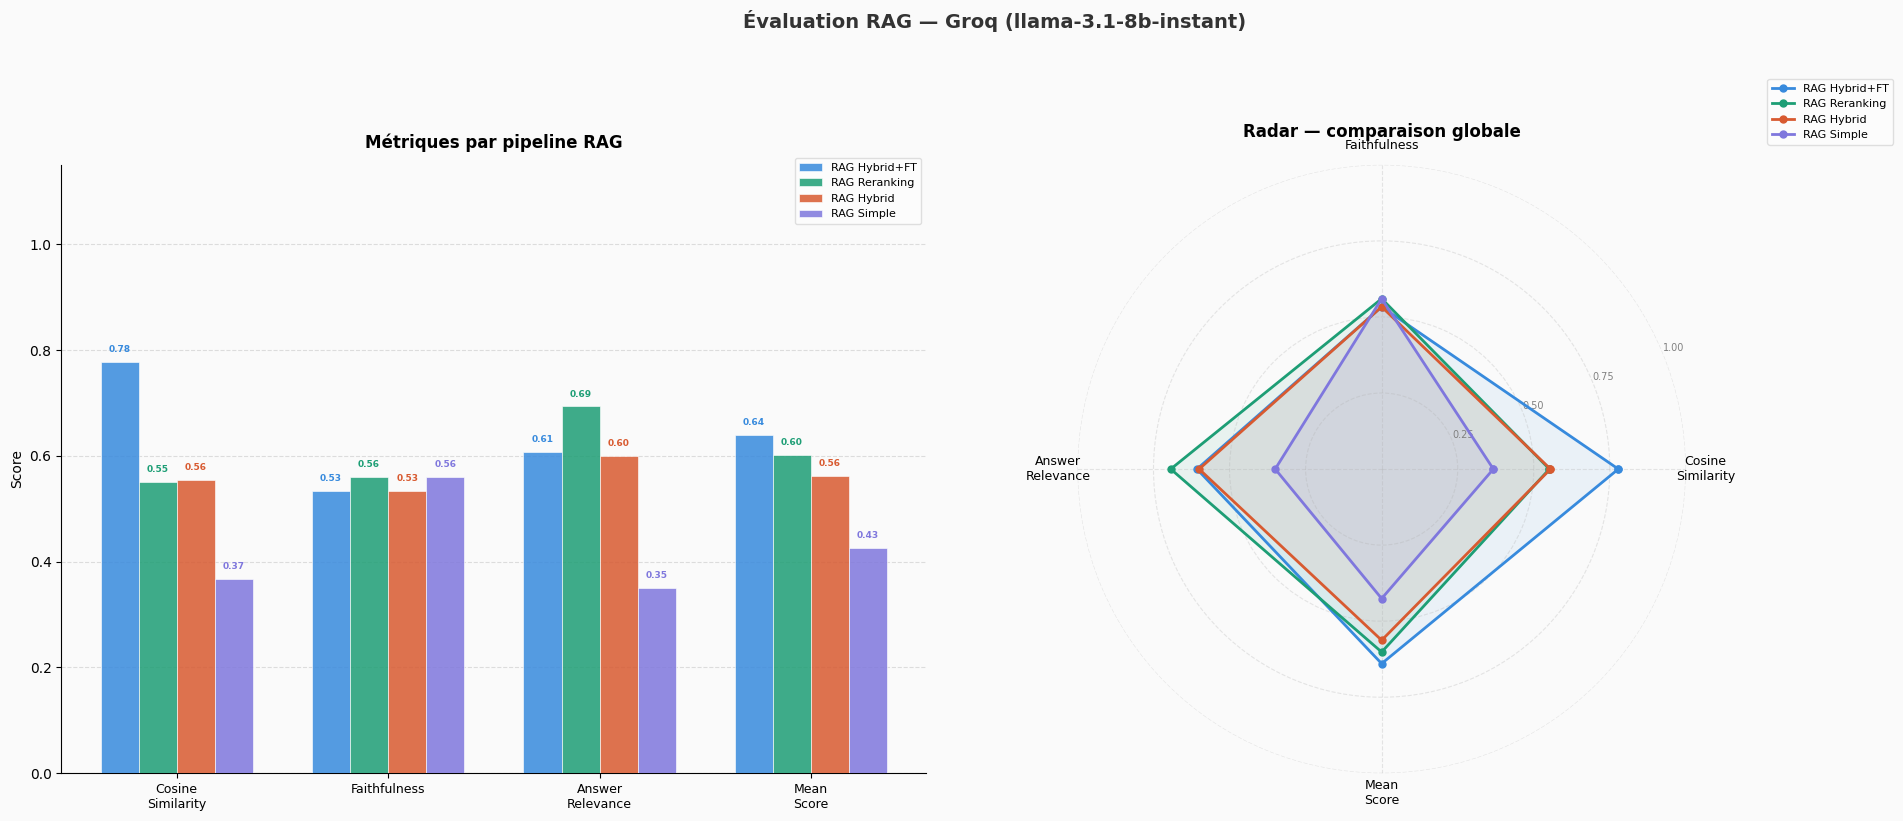

 Graphique sauvegardé : benchmark_rag.png


In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.patches import FancyBboxPatch

# ── Palette ──
palette = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']
pipeline_names = list(df_results.index)
metrics = ['Cosine Similarity', 'Faithfulness', 'Answer Relevance', 'Mean Score']

fig = plt.figure(figsize=(20, 8))
fig.patch.set_facecolor('#FAFAFA')

ax1 = fig.add_subplot(1, 2, 1)
ax1.set_facecolor('#FAFAFA')

n_metrics   = len(metrics)
n_pipelines = len(pipeline_names)
x           = np.arange(n_metrics)
width       = 0.18
offsets     = np.linspace(-(n_pipelines-1)/2, (n_pipelines-1)/2, n_pipelines) * width

for i, (name, color) in enumerate(zip(pipeline_names, palette)):
    vals = [df_results.loc[name, m] for m in metrics]
    bars = ax1.bar(x + offsets[i], vals, width=width,
                   color=color, alpha=0.85, label=name,
                   edgecolor='white', linewidth=0.5, zorder=3)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax1.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.015,
                     f'{val:.2f}', ha='center', va='bottom',
                     fontsize=6.5, color=color, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels([m.replace(' ', '\n') for m in metrics], fontsize=9)
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Score', fontsize=10)
ax1.set_title('Métriques par pipeline RAG', fontsize=12, fontweight='bold', pad=12)
ax1.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax1.set_axisbelow(True)
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(loc='upper right', fontsize=8, framealpha=0.6,
           edgecolor='#cccccc', bbox_to_anchor=(1, 1.02))


ax2 = fig.add_subplot(1, 2, 2, polar=True)
ax2.set_facecolor('#FAFAFA')

angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]  # ferme le polygone

for i, (name, color) in enumerate(zip(pipeline_names, palette)):
    vals = [df_results.loc[name, m] for m in metrics]
    # Remplace NaN par 0 pour l'affichage
    vals = [0 if np.isnan(v) else v for v in vals]
    vals += vals[:1]
    ax2.plot(angles, vals, 'o-', lw=2, label=name, color=color, markersize=5)
    ax2.fill(angles, vals, alpha=0.08, color=color)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels([m.replace(' ', '\n') for m in metrics], fontsize=9)
ax2.set_ylim(0, 1)
ax2.set_yticks([0.25, 0.50, 0.75, 1.00])
ax2.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=7, color='gray')
ax2.yaxis.grid(True, linestyle='--', alpha=0.3)
ax2.xaxis.grid(True, linestyle='--', alpha=0.3)
ax2.spines['polar'].set_visible(False)
ax2.set_title('Radar — comparaison globale', fontsize=12,
              fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
           fontsize=8, framealpha=0.6, edgecolor='#cccccc')

plt.suptitle('Évaluation RAG — Groq (llama-3.1-8b-instant)',
             fontsize=14, fontweight='bold', y=1.02, color='#333333')
plt.tight_layout()
plt.savefig("benchmark_rag.png", dpi=150, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print(" Graphique sauvegardé : benchmark_rag.png")

---
## Perspectives : Agent avec Recherche Web (Fallback Internet)

**Principe** : quand le modèle n'est pas sûr de sa réponse (chunks récupérés non pertinents, confiance faible), l'agent fait automatiquement une **recherche web** (DuckDuckGo) pour compléter ou vérifier sa réponse.

```
Question
   │
   ▼
┌──────────────────┐
│  Retriever        │──→ ChromaDB hybrid search
└────────┬─────────┘
         │ chunks
         ▼
┌──────────────────┐
│  Confidence Check │──→ Le cross-encoder évalue la pertinence
└────────┬─────────┘
         │
    ┌────┴────┐
    │         │
 Confiant  Pas sûr
    │         │
    ▼         ▼
┌────────┐  ┌──────────────────┐
│Génère  │  │ Web Search Agent  │──→ DuckDuckGo
│depuis  │  │ (recherche web)   │
│contexte│  └────────┬─────────┘
└────┬───┘           │ résultats web
     │               ▼
     │       ┌──────────────────┐
     │       │ Fusionne contexte │
     │       │ local + web       │
     │       └────────┬─────────┘
     │                │
     └────────┬───────┘
              ▼
       Réponse finale
```

In [36]:
# ── Outil de recherche web (DuckDuckGo) ──
!pip install -q ddgs
from ddgs import DDGS

def web_search(query: str, max_results: int = 3) -> str:
    """Recherche web via DuckDuckGo."""
    try:
        with DDGS() as ddgs:
            results = list(ddgs.text(query, max_results=max_results))
        snippets = [r.get('body', '') for r in results if r.get('body')]
        return '\n'.join(snippets) if snippets else ''
    except Exception as e:
        print(f'  [WebSearch] Erreur : {e}')
        return ''

# Test
print(web_search('linux forensics volatility', max_results=1)[:200])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.7 MB/s eta 0:00:00
TheVolatilityFoundation is an independent 501 (c) (3) non-profit organization that maintains and promotes open source memoryforensicswith TheVolatilityFramework.


In [37]:
from typing import TypedDict, List, Literal, Annotated
from langgraph.graph import StateGraph, START, END

# ── State partagé entre tous les agents ──
class MultiAgentState(TypedDict):
    question: str
    local_contexts: List[str]
    web_contexts: List[str]
    confidence: float
    context_sufficient: bool
    answer: str
    source: str           
    retry_count: int

MAX_RETRIES = 1
CONFIDENCE_THRESHOLD = 0.3
print('State multi-agent défini.')

State multi-agent défini.


In [39]:
# AGENT 1 : RETRIEVER — recherche hybride

def retriever_agent(state: MultiAgentState) -> MultiAgentState:
    question = state['question']
    print(f'  [Retriever] Recherche pour : "{question[:60]}..."')

    # Dense (ChromaDB)
    chroma_res = collection.query(
        query_texts=[question], n_results=9, include=['documents', 'metadatas'])
    dense_indices = [m['index'] for m in chroma_res['metadatas'][0]]

    # Sparse (TF-IDF)
    q_tfidf = tfidf.transform([question])
    sparse_scores = sklearn_cosine(q_tfidf, tfidf_matrix).flatten()
    sparse_top = np.argsort(sparse_scores)[::-1][:9].tolist()

    # RRF
    rrf = {}
    for rank, idx in enumerate(dense_indices):
        rrf[idx] = rrf.get(idx, 0) + 1.0/(60+rank+1)
    for rank, idx in enumerate(sparse_top):
        rrf[idx] = rrf.get(idx, 0) + 1.0/(60+rank+1)
    top = [i for i, _ in sorted(rrf.items(), key=lambda x: x[1], reverse=True)[:6]]

    # Reranking
    pairs = [[question, chunks[i]] for i in top]
    scores = reranker.predict(pairs)
    best_idx = np.argsort(scores)[::-1][:3]

    state['local_contexts'] = [chunks[top[i]] for i in best_idx]
    state['confidence'] = float(np.mean(scores[best_idx]))
    print(f'  [Retriever] {len(state["local_contexts"])} chunks, confiance={state["confidence"]:.3f}')
    return state

In [40]:
# AGENT 2 : VALIDATEUR — évalue la qualité du contexte
def validator_agent(state: MultiAgentState) -> MultiAgentState:
    """Évalue si le contexte récupéré est suffisant pour répondre."""
    conf = state['confidence']
    has_content = any(len(c.strip()) > 20 for c in state['local_contexts'])

    if conf >= CONFIDENCE_THRESHOLD and has_content:
        state['context_sufficient'] = True
        print(f'  [Validateur] ✓ Contexte suffisant (conf={conf:.3f})')
    else:
        state['context_sufficient'] = False
        print(f'  [Validateur] ✗ Contexte insuffisant (conf={conf:.3f}) → web search')
    return state

def route_after_validation(state: MultiAgentState) -> Literal['generator_agent', 'web_search_agent']:
    if state['context_sufficient']:
        return 'generator_agent'
    if state['retry_count'] >= MAX_RETRIES:
        print(f'  [Validateur] Max retries atteint → génération avec ce qu\'on a')
        return 'generator_agent'
    return 'web_search_agent'

In [41]:
# AGENT 3 : WEB SEARCH — recherche internet de complément

def web_search_agent(state: MultiAgentState) -> MultiAgentState:
    query = state['question'] + ' digital forensics'
    print(f'  [WebSearch] Recherche : "{query[:60]}..."')

    web_text = web_search(query, max_results=3)
    if web_text:
        state['web_contexts'] = [web_text]
        state['source'] = 'fused'
        print(f'  [WebSearch] {len(web_text)} caractères récupérés')
    else:
        state['web_contexts'] = []
        print('  [WebSearch] Aucun résultat')

    state['retry_count'] = state.get('retry_count', 0) + 1
    return state

In [43]:
# AGENT 4 : GÉNÉRATEUR — produit la réponse finale

def generator_agent(state: MultiAgentState) -> MultiAgentState:
    local = '\n\n'.join(state['local_contexts'])[:600]
    web = '\n\n'.join(state['web_contexts'])[:400] if state['web_contexts'] else ''

    if web:
        prompt = f"""Tu es un expert en digital forensics.
Tu as deux sources. Utilise-les pour répondre.

=== Base de connaissances ===
{local}

=== Recherche web ===
{web}

Question : {state['question']}
Réponse courte et exacte :
Réponse :"""
        state['source'] = 'fused'
    else:
        prompt = f"""Tu es un expert en digital forensics. Utilise UNIQUEMENT le contexte.

Contexte :
{local}

Question : {state['question']}
Réponse courte et exacte :
Réponse :"""
        state['source'] = 'local'

    inputs = ft_tokenizer(
        prompt, return_tensors='pt',
        truncation=True, max_length=480
    ).to('cuda')

    with torch.no_grad():
        outputs = ft_model.generate(
            **inputs, max_new_tokens=60,
            do_sample=False, temperature=0.0,
            pad_token_id=ft_tokenizer.eos_token_id)

    resp = ft_tokenizer.decode(outputs[0], skip_special_tokens=True)
    state['answer'] = resp.split('Réponse :')[-1].strip() if 'Réponse :' in resp else resp.strip()
    print(f'  [Générateur] ({state["source"]}) → "{state["answer"][:80]}"')
    return state

In [44]:
# GRAPHE MULTI-AGENT

workflow = StateGraph(MultiAgentState)

# Ajout des 4 agents
workflow.add_node('retriever_agent', retriever_agent)
workflow.add_node('validator_agent', validator_agent)
workflow.add_node('web_search_agent', web_search_agent)
workflow.add_node('generator_agent', generator_agent)

# Flux : START → Retriever → Validateur → (Generator | WebSearch → Generator)
workflow.add_edge(START, 'retriever_agent')
workflow.add_edge('retriever_agent', 'validator_agent')
workflow.add_conditional_edges('validator_agent', route_after_validation, {
    'generator_agent': 'generator_agent',
    'web_search_agent': 'web_search_agent'})
workflow.add_edge('web_search_agent', 'generator_agent')
workflow.add_edge('generator_agent', END)

multi_agent = workflow.compile()
print('Système multi-agent compilé (4 agents) !')

Système multi-agent compilé (4 agents) !


In [45]:
# ── Test sur quelques exemples ──
print('='*70 + '\n  TEST MULTI-AGENT\n' + '='*70)

for i in [0, 10, 50, 100]:
    if i >= len(questions): break
    q = questions[i]
    print(f'\n{"─"*70}\nQ{i}: {q}\n{"─"*70}')
    result = multi_agent.invoke({
        'question': q, 'local_contexts': [], 'web_contexts': [],
        'confidence': 0.0, 'context_sufficient': False,
        'answer': '', 'source': '', 'retry_count': 0})
    print(f'   Réponse : {result["answer"]}')
    print(f'   Source  : {result["source"]}')
    print(f'   GT      : {ground_truths[i]}')

  TEST MULTI-AGENT

──────────────────────────────────────────────────────────────────────
Q0: What was DOS boot floppy?
──────────────────────────────────────────────────────────────────────
  [Retriever] Recherche pour : "What was DOS boot floppy?..."
  [Retriever] 3 chunks, confiance=0.582
  [Validateur] ✓ Contexte suffisant (conf=0.582)
  [Générateur] (local) → "DOS boot floppy was used to boot the system. The boot floppy was created by the "
   Réponse : DOS boot floppy was used to boot the system. The boot floppy was created by the Digital Forensics Tool Testing (DFTT) project. The boot floppy contained the DOS operating system and the sechash.exe utility. The sechash.exe utility was used to calculate the hash value of the source
   Source  : local
   GT      : DOS boot floppy was inserted into the computer.

──────────────────────────────────────────────────────────────────────
Q10: Qu'est-ce que la technique Chip-Off en forensique et quand est-elle utilisée ?
──────────────────

In [46]:
# ── Évaluation multi-agent sur tout le dataset ──
agent_preds, agent_ctx, agent_sources = [], [], []

for q in tqdm(questions, desc='Multi-Agent'):
    result = multi_agent.invoke({
        'question': q, 'local_contexts': [], 'web_contexts': [],
        'confidence': 0.0, 'context_sufficient': False,
        'answer': '', 'source': '', 'retry_count': 0})
    agent_preds.append(result['answer'])
    agent_ctx.append(result['local_contexts'] + result['web_contexts'])
    agent_sources.append(result['source'])

agent_clean = [clean_response(p) for p in agent_preds]
agent_classic = compute_classic_metrics(agent_clean, ground_truths)

# Stats
from collections import Counter as Ctr
src_counts = Ctr(agent_sources)
print(f'\nSources utilisées : {dict(src_counts)}')
print(f'Web déclenché : {src_counts.get("fused",0)}/{len(questions)} ({100*src_counts.get("fused",0)/len(questions):.1f}%)')
print(f'Scores Multi-Agent : {agent_classic}')

Multi-Agent:   0%|          | 0/300 [00:00<?, ?it/s]

  [Retriever] Recherche pour : "What was DOS boot floppy?..."
  [Retriever] 3 chunks, confiance=0.582
  [Validateur] ✓ Contexte suffisant (conf=0.582)
  [Générateur] (local) → "DOS boot floppy was used to boot the system. The boot floppy was created by the "
  [Retriever] Recherche pour : "What was CHS in partition start address seccopy?..."
  [Retriever] 3 chunks, confiance=0.017
  [Validateur] ✗ Contexte insuffisant (conf=0.017) → web search
  [WebSearch] Recherche : "What was CHS in partition start address seccopy? digital for..."
  [WebSearch] 698 caractères récupérés
  [Générateur] (fused) → "CHS in partition start address seccopy was used a few times to copy a source par"
  [Retriever] Recherche pour : "What were analysis: expected results?..."
  [Retriever] 3 chunks, confiance=-0.625
  [Validateur] ✗ Contexte insuffisant (conf=-0.625) → web search
  [WebSearch] Recherche : "What were analysis: expected results? digital forensics..."
  [WebSearch] 716 caractères récupérés
  [Géné

In [47]:
# ── Comparaison finale avec le Multi-Agent ──
# Ajouter aux résultats existants
results_final = dict(results) if isinstance(results, dict) else {}

# Évaluation multi-agent avec Groq
sample_idx_agent = random.sample(range(len(questions)), min(5, len(questions)))
s_ans = [agent_clean[i] for i in sample_idx_agent]
s_ctx = [agent_ctx[i] for i in sample_idx_agent]
s_q   = [questions[i] for i in sample_idx_agent]
s_gt  = [ground_truths[i] for i in sample_idx_agent]

cos_agent = cosine_sim_score(agent_clean, ground_truths)
faith_agent = groq_faithfulness_batch(s_q, s_ans, s_ctx)
rel_agent = groq_relevance_batch(s_q, s_ans)

results_final['Multi-Agent'] = {
    'Cosine Similarity': round(cos_agent, 4),
    'Faithfulness': round(np.nanmean(faith_agent), 4),
    'Answer Relevance': round(np.nanmean(rel_agent), 4),
}

df_final = pd.DataFrame(results_final).T
df_final['Mean Score'] = df_final.mean(axis=1).round(4)
df_final = df_final.sort_values('Mean Score', ascending=False)

print('\n' + '═'*60 + '\n  COMPARAISON FINALE (incluant Multi-Agent)\n' + '═'*60)
display(df_final.style
    .background_gradient(cmap='RdYlGn', axis=0)
    .format('{:.4f}')
    .set_caption('Évaluation complète — RAG + Multi-Agent'))


════════════════════════════════════════════════════════════
  COMPARAISON FINALE (incluant Multi-Agent)
════════════════════════════════════════════════════════════


,Cosine Similarity,Faithfulness,Answer Relevance,Mean Score
Multi-Agent,0.7629,0.8400,0.7000,0.7676
RAG Hybrid+FT,0.7780,0.5333,0.6071,0.6395
RAG Reranking,0.5513,0.5600,0.6933,0.6015
RAG Hybrid,0.5550,0.5333,0.6000,0.5628
RAG Simple,0.3672,0.5600,0.3500,0.4257


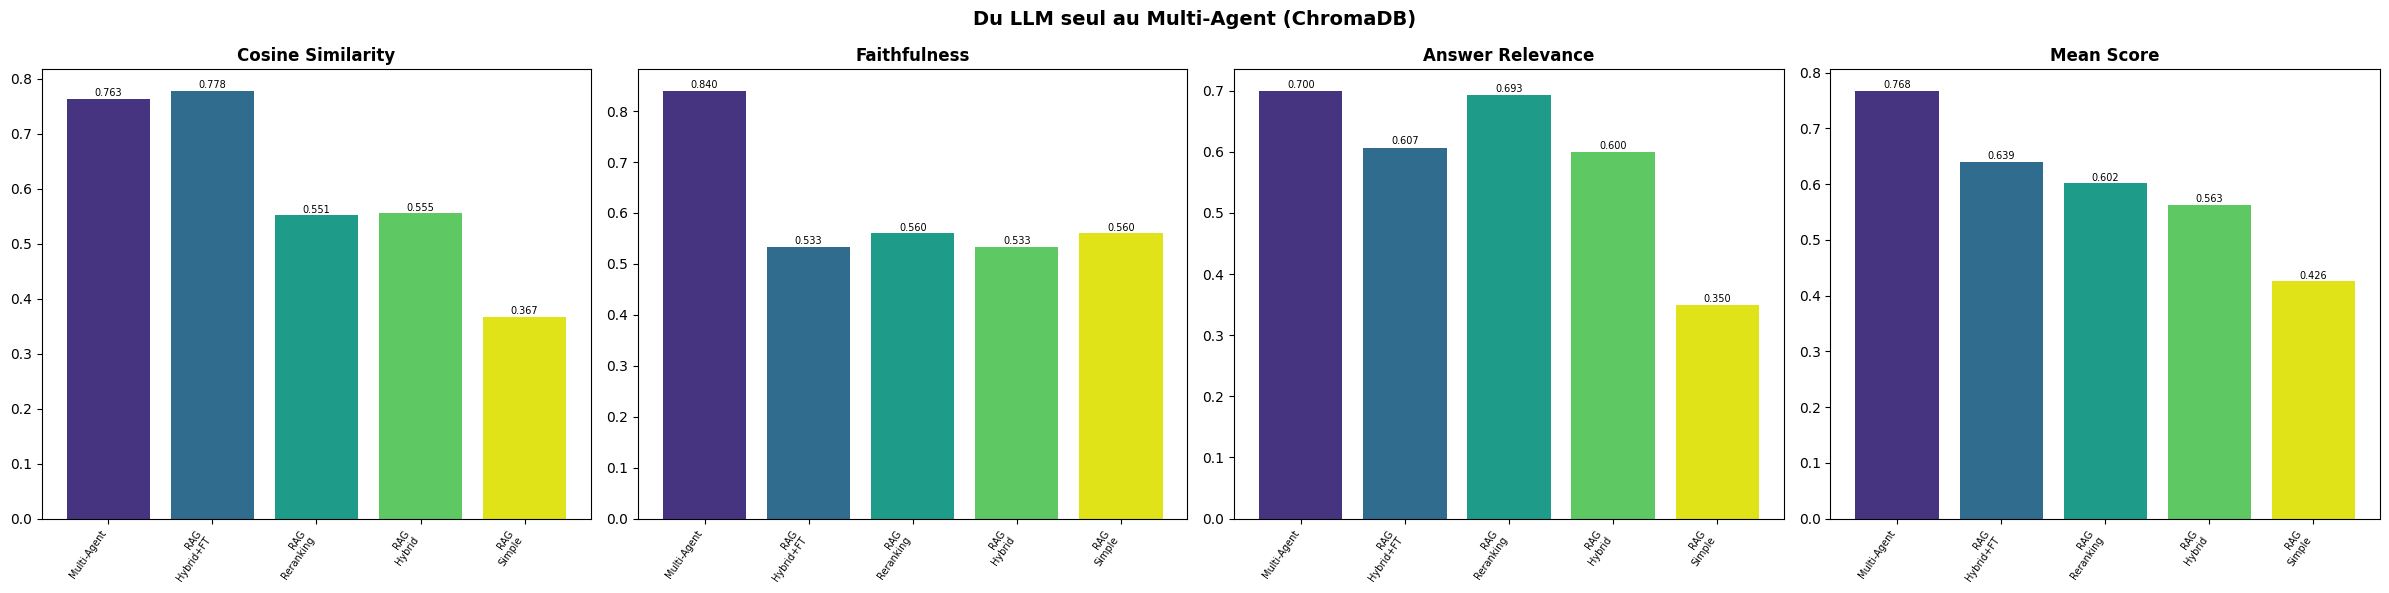

In [48]:
# ── Graphique final ──
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('Du LLM seul au Multi-Agent (ChromaDB)', fontsize=14, fontweight='bold')
n = len(df_final)
colors_f = plt.cm.viridis(np.linspace(0.15, 0.95, n))
labels_f = [l.replace(' ', '\n') for l in df_final.index]

for ax, metric in zip(axes, df_final.columns):
    vals = df_final[metric].values.astype(float)
    bars = ax.bar(range(n), vals, color=colors_f)
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(range(n))
    ax.set_xticklabels(labels_f, rotation=55, ha='right', fontsize=7)
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{v:.3f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('final_multiagent_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusion

### Pipeline complet

1. **300 Q/R en input** — pas de génération, chargement direct
2. **Sélection LLM** — Gemma / Qwen / Llama comparés sur métriques classiques
3. **Fine-tuning** — QLoRA (rank 32) du meilleur modèle
4. **RAG Simple** — ChromaDB cosine + top-3
5. **RAG Reranking** — ChromaDB top-10 → Cross-Encoder → top-3
6. **RAG Hybrid** — ChromaDB (dense) + TF-IDF (sparse) + RRF + Reranking
7. **RAG Hybrid + FT** — Meilleur retrieval + modèle fine-tuné
8. **Agent RAG + Web** — Quand la confiance est basse, recherche web automatique (DuckDuckGo) pour compléter le contexte local

### Évaluation multi-framework

| Framework | Métriques |
|---|---|
| **Classique** | Exact Match, F1 Token, ROUGE-L, BERTScore |
| **RAGAS** | Faithfulness, Answer Relevancy, Context Precision/Recall, Answer Correctness |
| **DeepEval** | Answer Relevancy, Faithfulness, Contextual Precision/Recall/Relevancy, Hallucination |

### Choix techniques

| Composant | Choix | Justification |
|---|---|---|
| Base vectorielle | **ChromaDB** | API simple, persistence native, embedding intégré |
| Recherche web | **DuckDuckGo** (via `duckduckgo-search`) | Gratuit, pas d'API key, rapide |
| Agent framework | **LangGraph** | Graphe d'état avec edges conditionnels, cycles, scalable |